In [1]:
import os
import sys
import warnings
import numpy as np
import pandas as pd
import polars as pl
import alphalens as al
import matplotlib.pyplot as plt
from datetime import datetime, time
import calendar

# 配置文件
try:
    import config_local as config
except ImportError:
    import config

# 导入数据接口sdk
import zenidatasdk as zd
client = zd.Client(
    base_url = config.ZENI_URL,
    username = config.ZENI_USERNAME,
    password = config.ZENI_PASSWORD,
)

# 忽视警告信息
warnings.filterwarnings(action = 'ignore')

In [70]:
# 历史回测区间
init_date = '2018-06-01'
start_date = '2018-09-01'
end_date = str(datetime.today().date())
index_symbol = rf"000852.XSHG"

# rf"000300.XSHG",  # 沪深300
# rf"000905.XSHG",  # 中证500
# rf"000852.XSHG",  # 中证1000
# rf"000016.XSHG",  # 上证50
# rf"399006.XSHE",  # 创业板

In [71]:
# 获取指数成分股数据据
index_weights_df = client.get_index_constituents_df(
    index_symbol = index_symbol,
    start_date = start_date,
    end_date = end_date
)
index_weights_df = index_weights_df.rename( columns = {"date": "datetime"} )
symbols = index_weights_df["symbol"].unique().tolist()
index_weights_df

,datetime,index_symbol,update_date,symbol,weight,display_name
0,2018-09-03,000852.XSHG,2018-08-31,000011.XSHE,0.056,深物业A
1,2018-09-03,000852.XSHG,2018-08-31,000016.XSHE,0.141,深康佳A
2,2018-09-03,000852.XSHG,2018-08-31,000018.XSHE,0.059,神城A退
3,2018-09-03,000852.XSHG,2018-08-31,000030.XSHE,0.092,富奥股份
4,2018-09-03,000852.XSHG,2018-08-31,000034.XSHE,0.138,神州数码
...,...,...,...,...,...,...
1846995,2026-04-20,000852.XSHG,2026-03-31,688776.XSHG,0.055,国光电气
1846996,2026-04-20,000852.XSHG,2026-03-31,688779.XSHG,0.143,五矿新能
1846997,2026-04-20,000852.XSHG,2026-03-31,688789.XSHG,0.084,宏华数科
1846998,2026-04-20,000852.XSHG,2026-03-31,688798.XSHG,0.073,艾为电子


In [93]:
# 获取日频bar数据
bars_1d_df = client.kline.get_kline_df(
    symbol=symbols,
    start_date=init_date,
    end_date=end_date,
    frequency="1d",
    adjust_type="post",
    market="cn_stock"
)
bars_1d_df

,open,high,low,close,pre_close,high_limit,low_limit,avg,volume,datetime,symbol,amount,paused
0,296.58,303.06,293.13,297.88,299.18,328.96,269.39,298.53,229846.45,2018-06-01,000006.XSHE,6.861530e+07,0.0
1,47.96,48.81,47.42,47.74,48.21,53.04,43.37,48.12,451617.44,2018-06-01,000011.XSHE,2.173406e+07,0.0
2,167.52,169.00,166.54,167.28,167.28,184.03,150.53,167.55,177780.24,2018-06-01,000012.XSHE,2.978911e+07,0.0
3,120.57,122.81,119.23,120.57,120.57,132.65,108.49,120.87,440830.62,2018-06-01,000016.XSHE,5.328162e+07,0.0
4,42.48,43.48,42.05,43.12,42.40,46.63,38.18,42.67,1704051.38,2018-06-01,000018.XSHE,7.270832e+07,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
3922478,11.15,11.43,11.11,11.35,11.22,13.46,8.98,11.28,29514863.10,2026-04-17,688779.XSHG,3.329475e+08,0.0
3922479,123.10,124.91,121.45,122.15,123.38,148.06,98.70,122.83,597921.40,2026-04-17,688788.XSHG,7.344141e+07,0.0
3922480,158.43,161.13,156.45,160.64,158.47,190.16,126.78,159.27,520559.57,2026-04-17,688789.XSHG,8.290749e+07,0.0
3922481,95.52,96.78,95.24,96.15,96.01,115.21,76.80,95.97,1514699.03,2026-04-17,688798.XSHG,1.453597e+08,0.0


In [73]:
# 获取日频估值数据
fundamental_1d_df = client.get_valuation_df(
    symbols=symbols,
    start_date=start_date,
    end_date=end_date,
    fields="datetime,symbol,market_cap,circulating_market_cap,turnover_ratio,pe_ratio,pb_ratio,dividend_ratio"
)
fundamental_1d_df


# 构建市值数据
# market_cap、circulating_market_cap
mkt_cap_name = "market_cap"
market_cap_df = fundamental_1d_df.set_index(["datetime", "symbol"])[[mkt_cap_name]]

# 负数和无穷值 & 对数处理
market_cap_df[mkt_cap_name] = np.where((market_cap_df[mkt_cap_name] <= 0) | (~np.isfinite(market_cap_df[mkt_cap_name])), 0, market_cap_df[mkt_cap_name])
market_cap_df[f"{mkt_cap_name}_log"] = np.log1p(market_cap_df[mkt_cap_name])
market_cap = market_cap_df[f"{mkt_cap_name}_log"]
market_cap

datetime    symbol     
2018-09-03  000006.XSHE    4.300880
            000011.XSHE    4.258864
            000012.XSHE    4.962715
            000016.XSHE    4.597583
            000018.XSHE    3.847007
                             ...   
2026-04-20  688779.XSHG    0.000000
            688788.XSHG    0.000000
            688789.XSHG    0.000000
            688798.XSHG    0.000000
            688800.XSHG    0.000000
Name: market_cap_log, Length: 3811147, dtype: float64

In [94]:
# 获取行业数据
industry_constituents_df = client.get_industry_constituents_composite_df(
    symbols=symbols,
    category="sw_l1",
    start_date=start_date,
    end_date=end_date
)

# 构建双重索引的行业数据
industries = industry_constituents_df.set_index(["datetime", "symbol"])["industry_name"]
industries

datetime    symbol     
2018-09-03  000048.XSHE    农林牧渔I
            000576.XSHE    农林牧渔I
            000592.XSHE    农林牧渔I
            000639.XSHE    农林牧渔I
            000735.XSHE    农林牧渔I
                           ...  
2026-04-20  600315.XSHG    美容护理I
            603193.XSHG    美容护理I
            603605.XSHG    美容护理I
            603983.XSHG    美容护理I
            605009.XSHG    美容护理I
Name: industry_name, Length: 3879955, dtype: object

In [95]:
# 多资产价格数据(开盘价买入)
prices_df = bars_1d_df[bars_1d_df["datetime"] >= start_date]
prices = prices_df.pivot_table(index="datetime", columns="symbol", values="open")
prices

symbol,000006.XSHE,000011.XSHE,000012.XSHE,000016.XSHE,000018.XSHE,000019.XSHE,000025.XSHE,000028.XSHE,000029.XSHE,000030.XSHE,...,688733.XSHG,688739.XSHG,688766.XSHG,688776.XSHG,688778.XSHG,688779.XSHG,688788.XSHG,688789.XSHG,688798.XSHG,688800.XSHG
datetime,,,,,,,,,,,,,,,,,,,,,
2018-09-03,240.61,42.10,137.77,94.95,19.22,47.29,50.13,182.68,24.25,13.75,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2018-09-04,239.72,42.83,141.77,94.03,19.51,47.67,50.51,185.61,24.25,13.65,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2018-09-05,240.61,42.28,140.62,94.72,20.16,48.04,51.00,184.67,24.25,13.84,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2018-09-06,236.61,40.93,139.48,93.34,21.03,46.86,49.02,182.25,24.25,13.46,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2018-09-07,233.94,40.89,138.34,93.57,20.45,46.76,49.93,179.61,24.25,13.65,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-04-13,442.03,38.61,162.93,75.26,NaN,51.39,44.84,148.23,48.24,21.41,...,27.53,27.92,1028.56,117.39,131.52,11.03,121.85,154.69,94.75,161.68
2026-04-14,445.13,38.70,166.22,78.91,NaN,52.36,45.06,145.17,47.72,21.71,...,29.60,27.48,1062.63,118.02,130.15,11.31,123.23,153.75,95.38,174.02
2026-04-15,456.49,39.16,165.49,79.89,NaN,51.52,45.20,145.85,47.53,22.05,...,30.70,27.69,1127.75,121.30,133.26,11.47,123.19,152.46,95.67,180.92


In [96]:
def f_0414(bars: pd.DataFrame, f_name: str = 'Std_of_shadow_to_close', roll_days: int = 20) -> pd.DataFrame:
    """
    factor_intro: 上下影线/收盘价的标准差
    category: 日频因子
    category_intro: 量价因子
    subcategory:
    subcategory_intro: 量价因子改进
    min_period: 20d
    source: 王琦, 2023, JASON's alpha: 基本面+量价复合策略, 东北证券
    author: 因子团队

    说明：使用每日K线的(上影线长度+下影线长度)/当日收盘价，并在月末计算当月的数据标准差，
    作为原始因子值。根据以上计算过程，判断因子方向为负向。
    因子逻辑：上下影线表现了多空博弈状态，通过选择上下影线总长度较短的标的，规避博弈剧烈、稳定性较差的股票

    Parameters
    ----------
    bars: pd.DataFrame
        日频 bars
        ['datetime', 'symbol', 'open', 'high', 'low', 'close']
    f_name: str
        因子名称，默认为 'f_db_0414'
    roll_days: int
        滚动窗口天数，默认为 20。研报原文为每月末计算当月标准差，
        本实现采用日频过去 roll_days 日滚动标准差替代。

    Returns
    -------
    factors: pd.DataFrame
        日频 factors
        ['datetime', 'symbol', 'factor_name', 'factor_value']
    """



    # 用语规范：
    # 柱体实体；Real Body
    # 上影线；Upper Shadow（规范）、Upper Wick（常用）
    # 下影线；Lower Shadow（规范）、Lower Wick（常用）
    # 柱体上沿：Top of the Body
    # 柱体的下沿：Bottom of the Body
    # 注：wick n. 灯芯、蜡烛芯


    # 定义阳线 与 非阳线（即阴线或十字星）
    # 再根据阳线布尔值，确定蜡烛柱体上下沿
    bars['is_rising'] = bars['open'] < bars['close']
    bars['body_top'] = np.where(bars['is_rising'], bars['close'], bars['open'])
    bars['body_bottom'] = np.where(bars['is_rising'], bars['open'], bars['close'])

    # 计算上下影线长度
    bars['upper_shadow'] = bars['high'] - bars['body_top']
    bars['lower_shadow'] = bars['body_bottom'] - bars['low']

    # 计算上下影线长度之和与收盘价的比值 Std of shadow to close
    bars = bars.set_index(['datetime', 'symbol'])
    bars['factor_value'] = (bars['upper_shadow'] + bars['lower_shadow'])/bars['close']
    roll_stats = bars.groupby('symbol')['factor_value'].rolling(window = roll_days).agg('std').reset_index(level = 0, drop = True)

    bars = pd.merge(left = bars[[]], right = roll_stats, on = ['datetime', 'symbol'], how = 'left')
    bars['factor_value'] *= -1
    bars['factor_name'] = f_name

    return bars

In [97]:
# 计算因子数据
factors_df = f_0414(bars = bars_1d_df, f_name = 'Std_of_shadow_to_close', roll_days = 20)
# 因子值 shift 1 转换成实际使用时间(T+1)
factors_df["factor_value"] = factors_df.groupby('symbol')['factor_value'].transform(lambda x: x.shift(1))
factors_df

factor_value factor_name
datetime   symbol                               
2018-06-01 000006.XSHE           NaN   f_db_0414
           000011.XSHE           NaN   f_db_0414
           000012.XSHE           NaN   f_db_0414
           000016.XSHE           NaN   f_db_0414
           000018.XSHE           NaN   f_db_0414
...                              ...         ...
2026-04-17 688779.XSHG     -0.016800   f_db_0414
           688788.XSHG     -0.011750   f_db_0414
           688789.XSHG     -0.012752   f_db_0414
           688798.XSHG     -0.007970   f_db_0414
           688800.XSHG     -0.011690   f_db_0414

[3922107 rows x 2 columns]

In [98]:
# 与指数的交易日历、历史成分股数据对齐
factors_df = pd.merge(index_weights_df[["datetime", "symbol"]], factors_df, how="left", on=["datetime", "symbol"])
# 转换成[datetime, symbol]双重索引的factor_table
factors = factors_df.pivot_table(index=["datetime", "symbol"], columns="factor_name", values="factor_value")
factors

factor_name             f_db_0414
datetime   symbol                
2018-09-03 000011.XSHE  -0.021138
           000016.XSHE  -0.009571
           000018.XSHE  -0.013027
           000030.XSHE  -0.011007
           000034.XSHE  -0.014379
...                           ...
2026-04-17 688776.XSHG  -0.006807
           688779.XSHG  -0.016800
           688789.XSHG  -0.012752
           688798.XSHG  -0.007970
           688800.XSHG  -0.011690

[1845976 rows x 1 columns]

In [85]:
factors.info()

<class 'pandas.core.frame.DataFrame'>
MultiIndex: 1845976 entries, (Timestamp('2018-09-03 00:00:00'), '000011.XSHE') to (Timestamp('2026-04-17 00:00:00'), '688800.XSHG')
Data columns (total 1 columns):
 #   Column     Dtype  
---  ------     -----  
 0   f_db_0414  float64
dtypes: float64(1)
memory usage: 21.2+ MB


五、合并因子与目标变量

In [99]:
# 调用alphalens进行数据清洗
factor_data = al.utils.get_clean_factor_and_forward_returns(
    factor=factors,
    prices=prices,
    periods=(1, 5, 20),
    bins=None,
    quantiles=5,
    groupby=None,
    groupby_labels=None,
    binning_by_group=False,
    filter_zscore=20,
    max_loss=0.25,
    zero_aware=False,
    cumulative_returns=True
)
factor_data

Dropped 1.1% entries from factor data: 1.1% in forward returns computation and 0.0% in binning phase (set max_loss=0 to see potentially suppressed Exceptions).
max_loss is 25.0%, not exceeded: OK!


1D        5D       20D    factor  \
date       asset                                                 
2018-09-03 000011.XSHE  0.017340 -0.014727 -0.036580 -0.021138   
           000016.XSHE -0.009689 -0.024223  0.019484 -0.009571   
           000018.XSHE  0.015088  0.075442 -0.041623 -0.013027   
           000030.XSHE -0.007273 -0.011636 -0.024000 -0.011007   
           000034.XSHE  0.002224  0.108008  0.023480 -0.014379   
...                          ...       ...       ...       ...   
2026-03-19 688776.XSHG -0.042945 -0.085147 -0.100825 -0.010482   
           688779.XSHG -0.019469 -0.022124 -0.013274 -0.006949   
           688789.XSHG -0.028605 -0.035602 -0.027500 -0.010076   
           688798.XSHG  0.005272 -0.044166 -0.049836 -0.008513   
           688800.XSHG  0.076434  0.034086  0.095710 -0.023334   

                        factor_quantile  
date       asset                         
2018-09-03 000011.XSHE                1  
           000016.XSHE                3  
           000018.XSHE                2  
           000030.XSHE                3  
           000034.XSHE                2  
...                                 ...  
2026-03-19 688776.XSHG                3  
           688779.XSHG                4  
           688789.XSHG                3  
           688798.XSHG                3  
           688800.XSHG                1  

[1825976 rows x 5 columns]

六、alphalens因子测试

Quantiles Statistics


,min,max,mean,std,count,count %
factor_quantile,,,,,,
1,-0.077672,-0.009891,-0.018989,0.005447,365200,20.000263
2,-0.024448,-0.007324,-0.012921,0.002608,365194,19.999934
3,-0.018666,-0.005948,-0.010404,0.002246,365188,19.999606
4,-0.015658,-0.004507,-0.008400,0.002018,365194,19.999934
5,-0.013384,0.000000,-0.006028,0.001936,365200,20.000263


Returns Analysis


,1D,5D,20D
Ann. alpha,0.124,0.117,0.098
beta,-0.178,-0.149,-0.161
Mean Period Wise Return Top Quantile (bps),1.115,1.141,0.853
Mean Period Wise Return Bottom Quantile (bps),-4.844,-4.357,-3.310
Mean Period Wise Spread (bps),5.959,5.520,4.160


<Figure size 640x480 with 0 Axes>

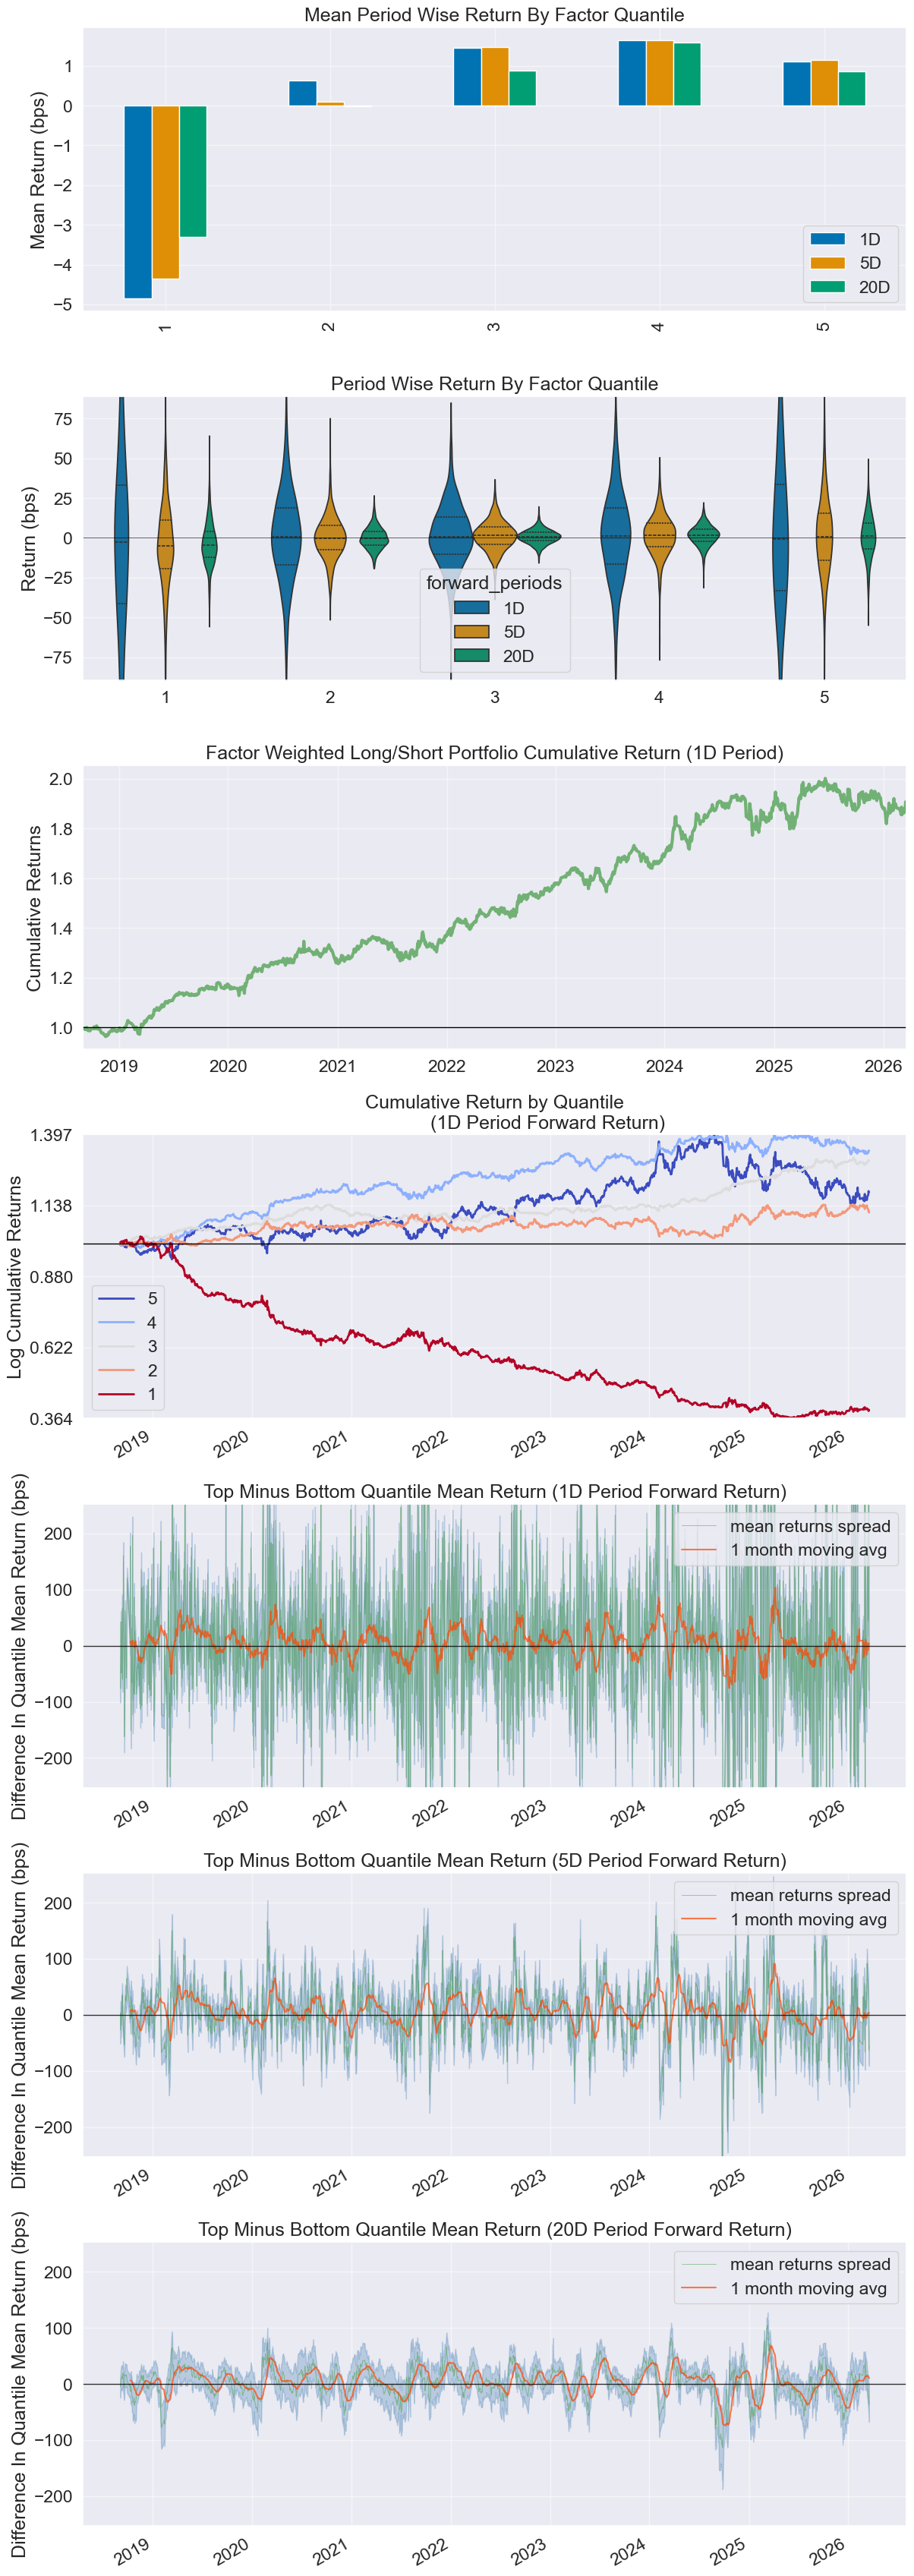

Information Analysis


,1D,5D,20D
IC Mean,0.044,0.067,0.089
IC Std.,0.169,0.160,0.165
Risk-Adjusted IC,0.261,0.419,0.539
t-stat(IC),11.161,17.892,23.031
p-value(IC),0.000,0.000,0.000
IC Skew,-0.024,-0.040,0.003
IC Kurtosis,0.212,0.278,0.011


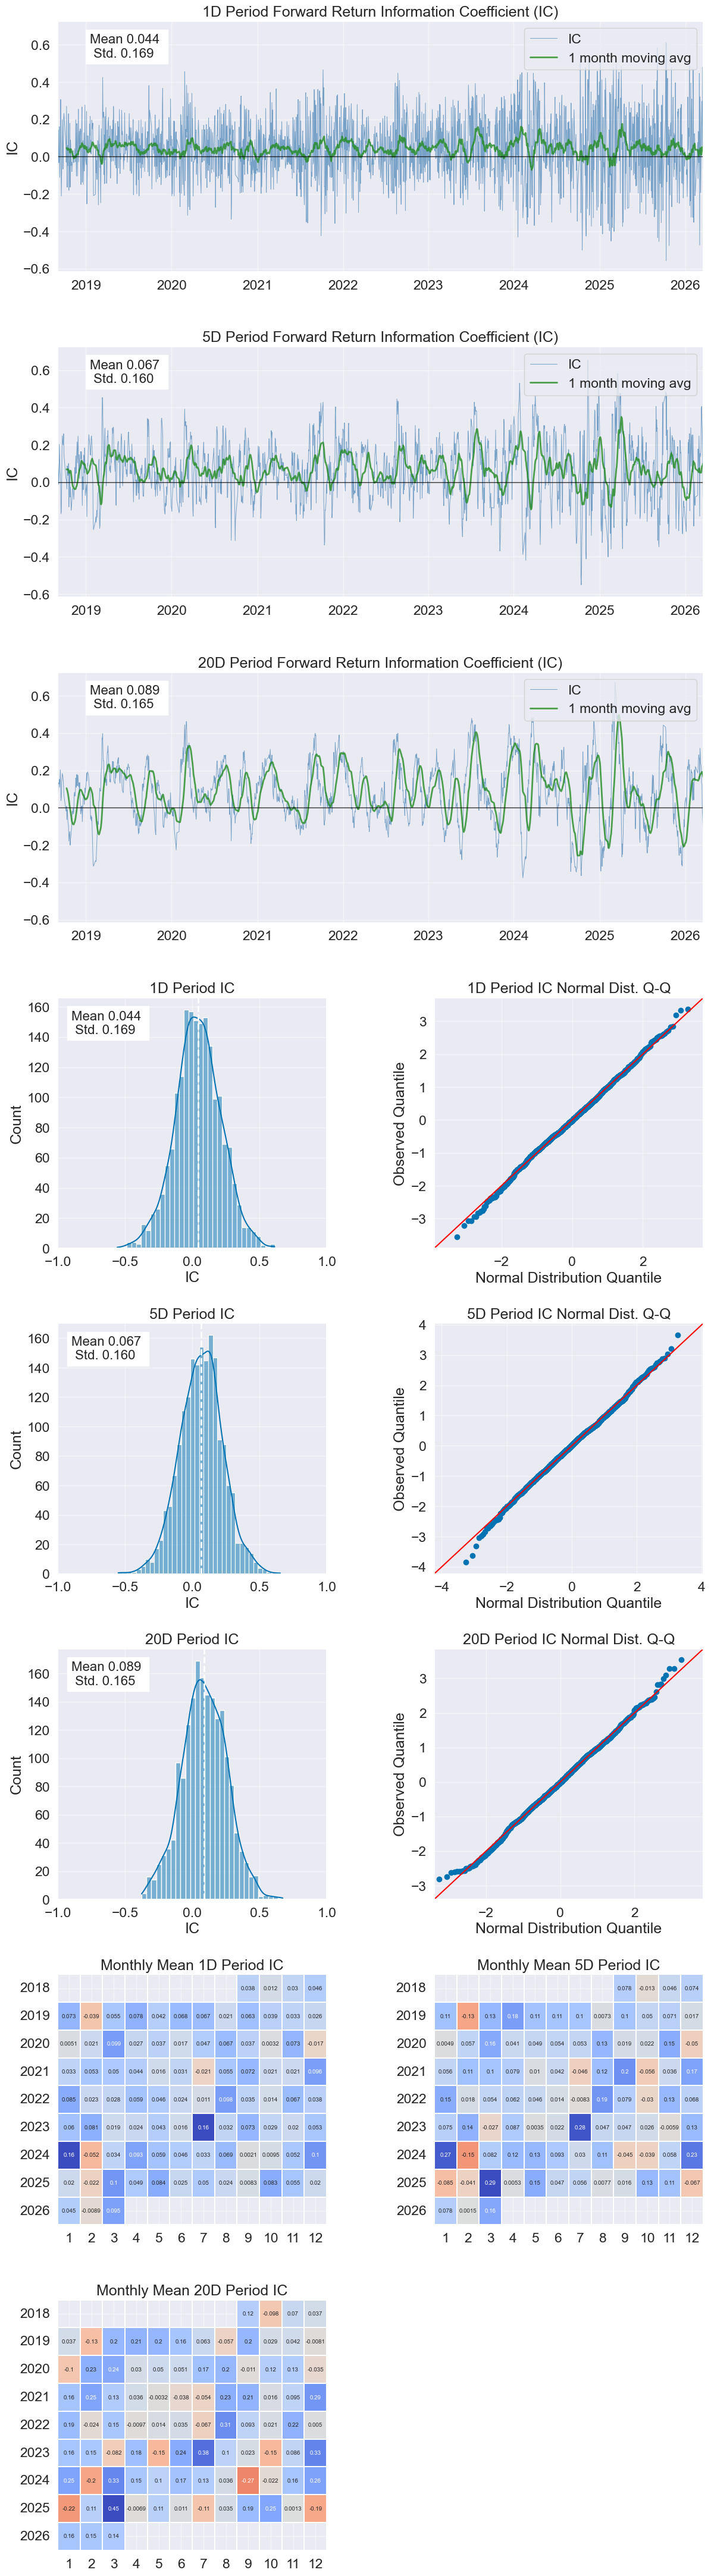

Turnover Analysis


,1D,5D,20D
Quantile 1 Mean Turnover,0.071,0.231,0.606
Quantile 2 Mean Turnover,0.158,0.425,0.742
Quantile 3 Mean Turnover,0.189,0.479,0.763
Quantile 4 Mean Turnover,0.177,0.451,0.742
Quantile 5 Mean Turnover,0.085,0.244,0.535


,1D,5D,20D
Mean Factor Rank Autocorrelation,0.975,0.863,0.465


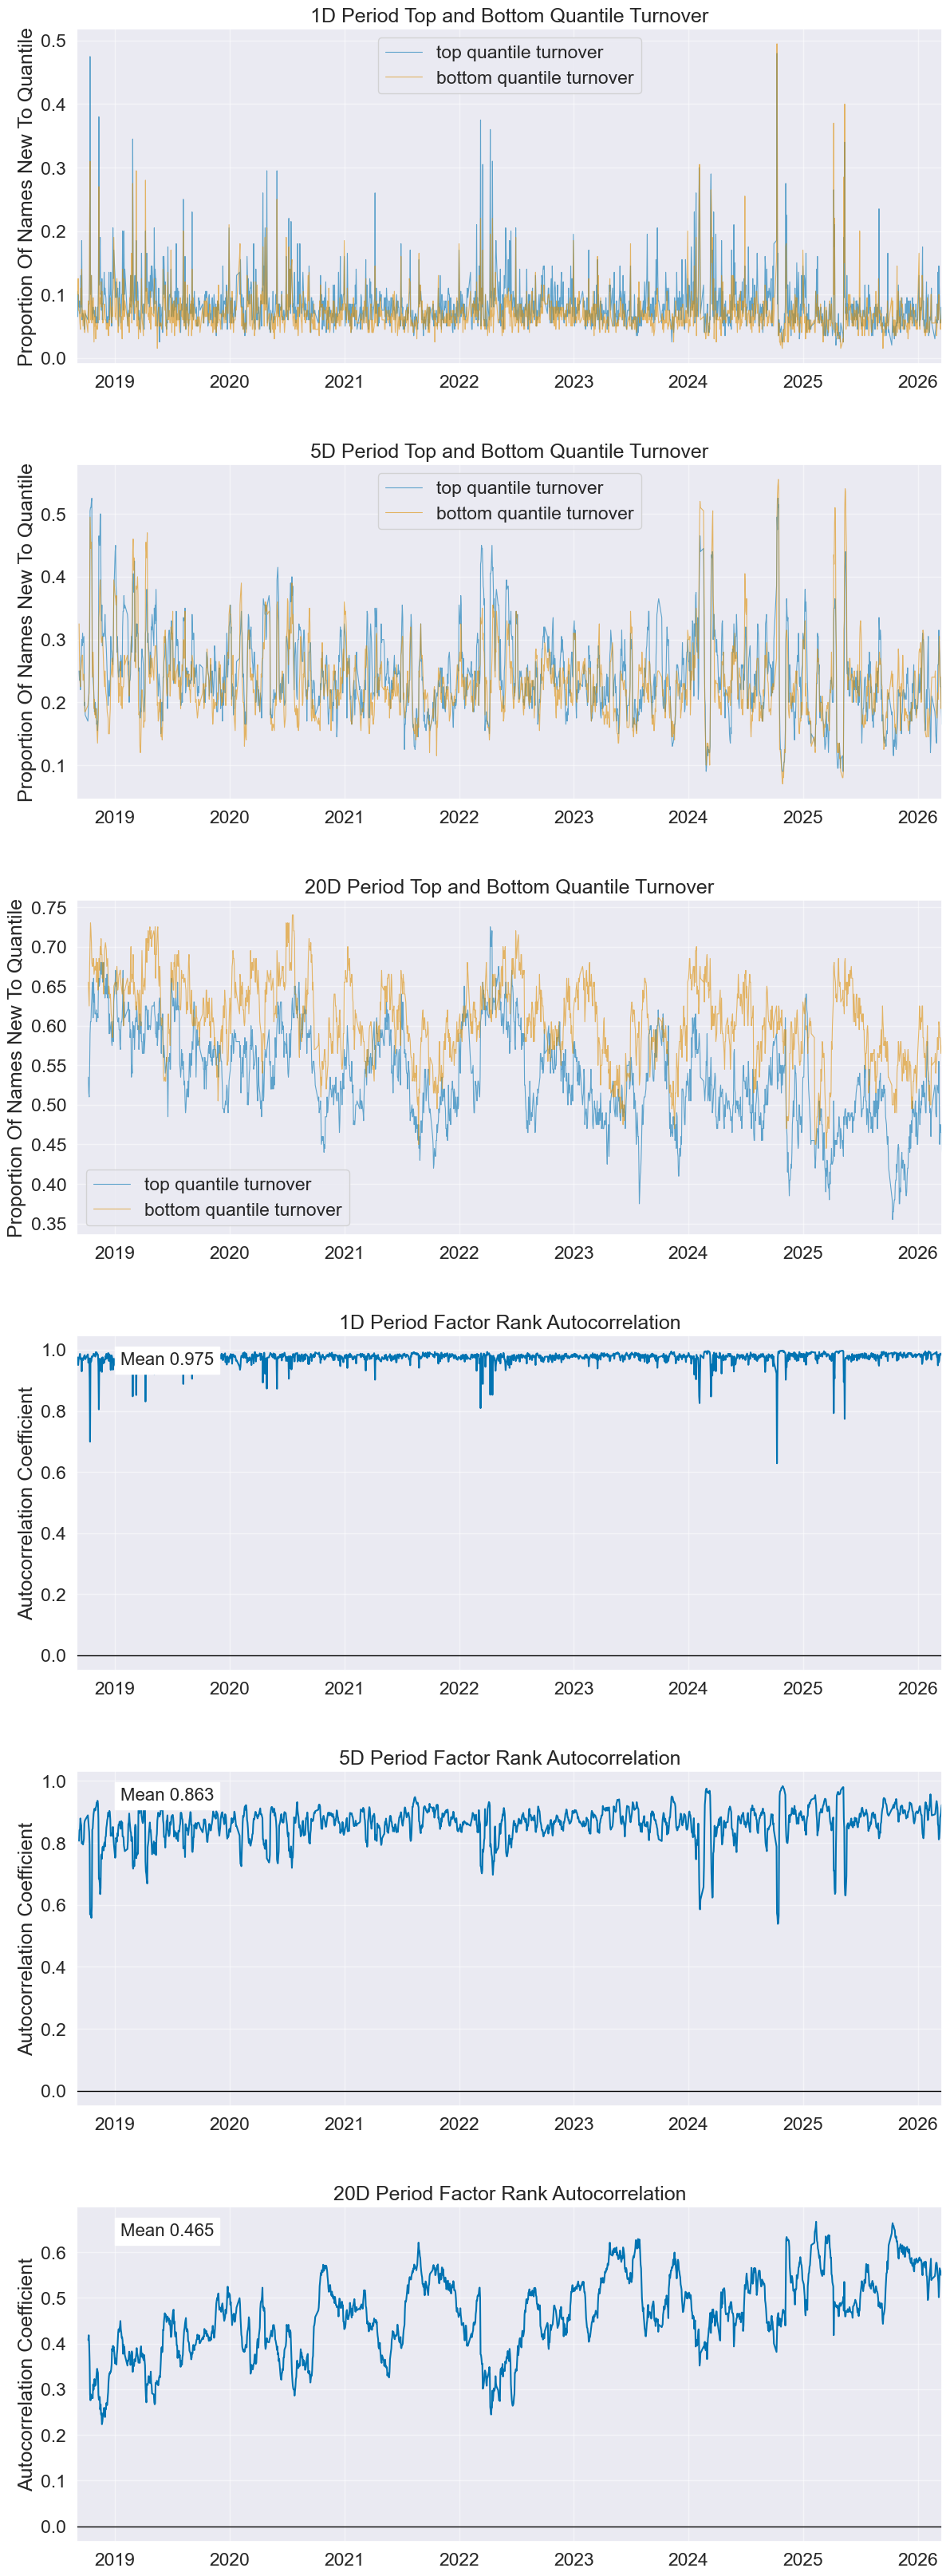

In [100]:
# 调用alphalens进行因子评估
al.tears.create_full_tear_sheet(
    factor_data=factor_data,
    long_short=True,
    group_neutral=False,
    by_group=False
)